# Scam Title Classification with PyIBL and Sentence Transformers

This notebook shows how to use embedding-based similarity inside a PyIBL agent to classify short email titles as **scam** or **safe**.

You will:
- load a tiny labeled dataset
- configure embedding-aware similarity on the `title` attribute
- train online and plot a learning curve
- visualize how the sentence-transformer fits into the IBL decision loop

## Requirements

Install optional dependencies if needed:

- `pip install sentence-transformers`
- `pip install matplotlib`

In [1]:
from pathlib import Path
import csv
import importlib
import random

import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise SystemExit(
        "This notebook requires matplotlib. Install it with: pip install matplotlib"
    ) from exc

try:
    SentenceTransformer = importlib.import_module("sentence_transformers").SentenceTransformer
except ImportError as exc:
    raise SystemExit(
        "This notebook requires sentence-transformers. Install it with: pip install sentence-transformers"
    ) from exc

from pyibl import Agent

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_SEED = 7

PyIBL version 5.2.3.dev1


In [2]:
data_path = Path("scam_titles.csv")
if not data_path.exists():
    data_path = Path("examples/embedding/scam_titles.csv")

with open(data_path, newline="", encoding="utf-8") as infile:
    examples = list(csv.DictReader(infile))

print(f"Loaded {len(examples)} labeled titles from {data_path}")
examples[:3]

Loaded 10 labeled titles from scam_titles.csv


[{'title': 'Urgent: Verify your account now', 'label': 'scam'},
 {'title': 'Action required: payroll login reset', 'label': 'scam'},
 {'title': 'You have won a gift card', 'label': 'scam'}]

## Build the Embedding-Aware Agent

The agent stores experiences over `(title, label)` choices.

Embedding-based similarity is enabled on `title` so semantically similar titles can partially match previously seen examples.

In [3]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
encoder = SentenceTransformer(model_name)

def make_agent():
    # default_utility avoids cold-start errors before memory is populated.
    agent = Agent(attributes=["title", "label"], mismatch_penalty=1, default_utility=0.5)
    agent.embedding(function=encoder)
    agent.embedding("title")
    return agent

agent = make_agent()
print("Embedding-enabled attributes:", agent.embedding())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding-enabled attributes: ('title',)


## Train Online and Track Learning

Each trial asks the agent to choose between two labels (`scam` vs `safe`) for one title.

The response reward is `1` for correct and `0` for incorrect, then we plot accuracy over time.

In [4]:
N_RUNS = 10
EPOCHS = 20

def run_epoch(agent, rows, rng):
    shuffled = rows[:]
    rng.shuffle(shuffled)
    correct = 0
    trial_hits = []

    for row in shuffled:
        options = [
            {"title": row["title"], "label": "scam"},
            {"title": row["title"], "label": "safe"},
        ]
        prediction = agent.choose(options)
        is_correct = prediction["label"] == row["label"]
        agent.respond(1 if is_correct else -1)

        correct += int(is_correct)
        trial_hits.append(int(is_correct))

    return correct / len(shuffled), trial_hits

def train_agent(rows, epochs=EPOCHS, seed=RANDOM_SEED):
    rng = random.Random(seed)
    trained = make_agent()
    epoch_accuracy = []
    trial_accuracy = []

    for _ in range(epochs):
        acc, hits = run_epoch(trained, rows, rng)
        epoch_accuracy.append(acc)
        trial_accuracy.extend(hits)

    return trained, np.asarray(epoch_accuracy, dtype=float), np.asarray(trial_accuracy, dtype=float)

all_epoch_accuracy = []
all_cumulative_accuracy = []

for run_idx in range(N_RUNS):
    trained_agent, epoch_accuracy, trial_accuracy = train_agent(
        examples,
        epochs=EPOCHS,
        seed=RANDOM_SEED + run_idx,
    )
    all_epoch_accuracy.append(epoch_accuracy)
    cumulative = np.cumsum(trial_accuracy) / np.arange(1, len(trial_accuracy) + 1)
    all_cumulative_accuracy.append(cumulative)

epoch_matrix = np.vstack(all_epoch_accuracy)
cumulative_matrix = np.vstack(all_cumulative_accuracy)

epoch_mean = epoch_matrix.mean(axis=0)
epoch_sem = epoch_matrix.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
cumulative_mean = cumulative_matrix.mean(axis=0)
cumulative_sem = cumulative_matrix.std(axis=0, ddof=1) / np.sqrt(N_RUNS)

print(f"Runs: {N_RUNS}, epochs per run: {EPOCHS}")
print(f"Mean epoch-1 accuracy:  {epoch_mean[0]:.2f} ± {epoch_sem[0]:.2f}")
print(f"Mean final-epoch accuracy: {epoch_mean[-1]:.2f} ± {epoch_sem[-1]:.2f}")

Runs: 10, epochs per run: 20
Mean epoch-1 accuracy:  0.40 ± 0.03
Mean final-epoch accuracy: 0.65 ± 0.05


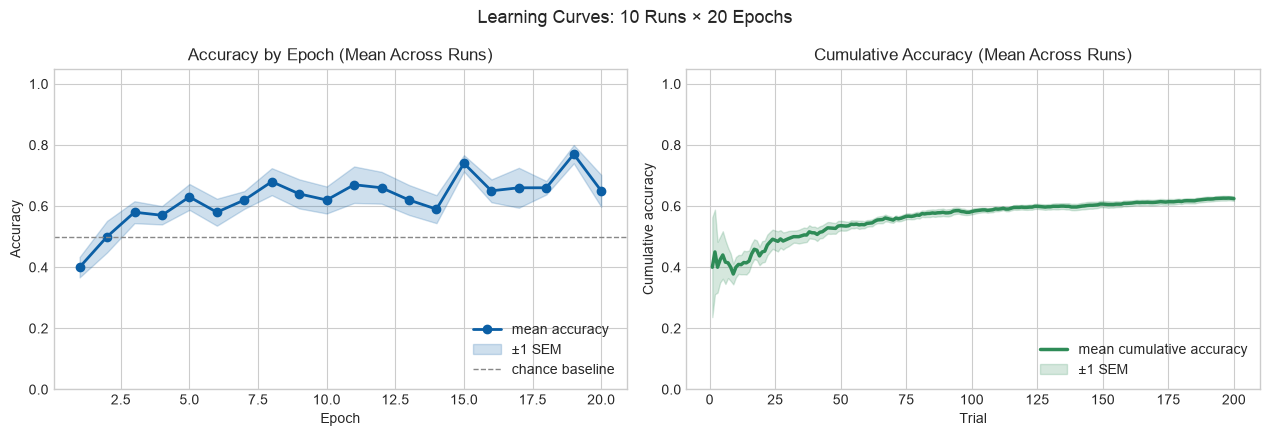

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))

epoch_x = np.arange(1, EPOCHS + 1)
axes[0].plot(epoch_x, epoch_mean, marker="o", linewidth=2, color="#0B5FA5", label="mean accuracy")
axes[0].fill_between(
    epoch_x,
    np.clip(epoch_mean - epoch_sem, 0, 1),
    np.clip(epoch_mean + epoch_sem, 0, 1),
    color="#0B5FA5",
    alpha=0.20,
    label="±1 SEM",
)
axes[0].axhline(0.5, color="#888888", linestyle="--", linewidth=1, label="chance baseline")
axes[0].set_title("Accuracy by Epoch (Mean Across Runs)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="lower right")

trial_x = np.arange(1, cumulative_mean.size + 1)
axes[1].plot(trial_x, cumulative_mean, linewidth=2.5, color="#2E8B57", label="mean cumulative accuracy")
axes[1].fill_between(
    trial_x,
    np.clip(cumulative_mean - cumulative_sem, 0, 1),
    np.clip(cumulative_mean + cumulative_sem, 0, 1),
    color="#2E8B57",
    alpha=0.20,
    label="±1 SEM",
)
axes[1].set_title("Cumulative Accuracy (Mean Across Runs)")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Cumulative accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="lower right")

fig.suptitle(f"Learning Curves: {N_RUNS} Runs × {EPOCHS} Epochs", fontsize=13)
fig.tight_layout()
plt.show()

## How SentenceTransformer Fits into the IBL Loop

This diagram summarizes the full decision process used in the notebook.

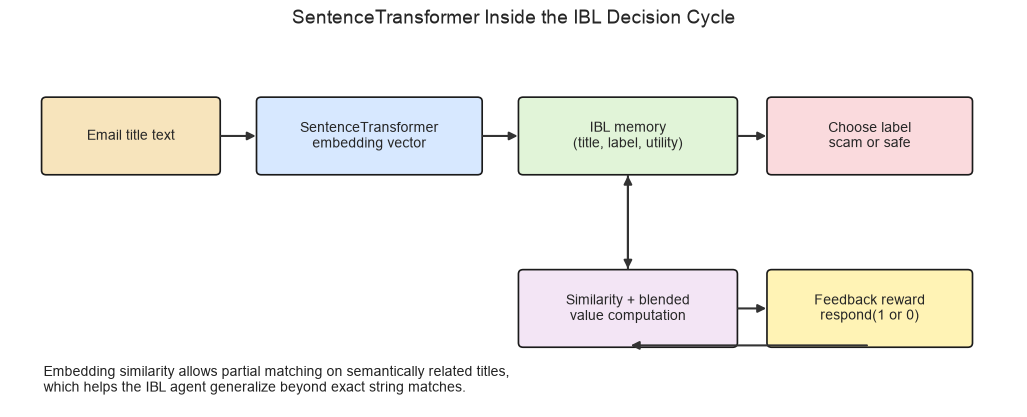

In [6]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

def draw_box(ax, x, y, w, h, text, color):
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03,rounding_size=0.07",
                           linewidth=1.2, edgecolor="#1A1A1A", facecolor=color)
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                mutation_scale=12, linewidth=1.5, color="#333333"))

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_xlim(0, 15)
ax.set_ylim(0, 6)
ax.axis("off")

draw_box(ax, 0.5, 3.8, 2.6, 1.2, "Email title text", "#F7E4BC")
draw_box(ax, 3.7, 3.8, 3.3, 1.2, "SentenceTransformer\nembedding vector", "#D7E8FF")
draw_box(ax, 7.6, 3.8, 3.2, 1.2, "IBL memory\n(title, label, utility)", "#E1F4D8")
draw_box(ax, 11.3, 3.8, 3.0, 1.2, "Choose label\nscam or safe", "#FADADD")

draw_box(ax, 7.6, 1.0, 3.2, 1.2, "Similarity + blended\nvalue computation", "#F3E5F5")
draw_box(ax, 11.3, 1.0, 3.0, 1.2, "Feedback reward\nrespond(1 or 0)", "#FFF3B5")

draw_arrow(ax, 3.1, 4.4, 3.7, 4.4)
draw_arrow(ax, 7.0, 4.4, 7.6, 4.4)
draw_arrow(ax, 10.8, 4.4, 11.3, 4.4)
draw_arrow(ax, 9.2, 3.8, 9.2, 2.2)
draw_arrow(ax, 10.8, 1.6, 11.3, 1.6)
draw_arrow(ax, 12.8, 1.0, 9.2, 1.0)
draw_arrow(ax, 9.2, 2.2, 9.2, 3.8)

ax.text(0.5, 0.25,
        "Embedding similarity allows partial matching on semantically related titles,\n"
        "which helps the IBL agent generalize beyond exact string matches.",
        fontsize=10, color="#222222")

ax.set_title("SentenceTransformer Inside the IBL Decision Cycle", fontsize=14, pad=10)
plt.show()

## Quick Prediction Demo

Try a new title with the trained agent.

In [7]:
query = "Urgent: your mailbox storage is full, verify now"
options = [
    {"title": query, "label": "scam"},
    {"title": query, "label": "safe"},
]

choice, details = trained_agent.choose(options, details=True)
print(f"Predicted label for query: {choice['label']}")
print("Top retrieval summary:")
for item in details:
    print(f"  {item['choice']['label']}: blended_value={item['blended_value']:.3f}")

# Clear pending decision without external label feedback.
trained_agent.respond()

Predicted label for query: safe
Top retrieval summary:
  safe: blended_value=0.584
  scam: blended_value=0.321
